# ANTEX parsers

Antenna Exchange Format ([ANTEX](https://files.igs.org/pub/data/format/antex14.txt)) isstandard text format for the exchnge of GNSS antenna calibration data. Midgard provides a parser for reading the ANTEX format.

## Use of ANTEX parser

An example is shown, how to use the **antex** parser:

In [1]:
# Import parsers package
from midgard import parsers

# Read file by generating an instance of a Parser class
p = parsers.parse_file(parser_name="antex", file_path="../examples/parsers/igs20.atx")

# Generate dictionary based on read file data
data = p.as_dict()

The **data** dictionary has GNSS satellite PRN or receiver antenna as key. The GNSS satellite antenna corrections are time dependent and saved with "valid from" datetime object entry. The dictionary looks like:

```
        dout = { <prn> : { <valid from>: { cospar_id:   <value>,
                                           sat_code:    <value>,
                                           sat_type:    <value>,
                                           valid_until: <value>,
                                           azimuth:     <list with azimuth values>,
                                           elevation:   <list with elevation values>,
                                           <frequency>: { azi: [<list with azimuth-elevation dependent corrections>],
                                                          neu: [north, east, up],
                                                          noazi: [<list with elevation dependent corrections>] }}},

                 <receiver antenna> : { azimuth:     <list with azimuth values>,
                                        elevation:   <list with elevation values>,
                                        <frequency>: { azi: [<array with azimuth-elevation dependent corrections>],
                                                       neu: [north, east, up],
                                                       noazi: [<list with elevation dependent corrections>] }}}
                                                       
```
with following entries:

| Value              | Type              | Description                                                            |
| :----------------- | :---------------- | :--------------------------------------------------------------------- |
| azi                | numpy.ndarray     | Array with azimuth-elevation dependent antenna correction in [mm] with |
|                    |                   | the shape: number of azimuth values x number of elevation values.      |
| azimuth            | numpy.ndarray     | List with azimuth values in [rad] corresponding to antenna corrections |
|                    |                   | given in `azi`.                                                        |
| cospar_id          | str               | COSPAR ID <yyyy-xxxa>: yyyy -> year when the satellite was put in      |
|                    |                   | orbit, xxx -> sequential satellite number for that year, a -> alpha    |
|                    |                   | numeric sequence number within a launch                                |
| elevation          | numpy.ndarray     | List with elevation values in [rad] corresponding to antenna           |
|                    |                   | corrections given in `azi` or `noazi`.                                 |
| <frequency>        | str               | Frequency identifier (e.g. G01 - GPS L1)                               |
| neu                | list              | North, East and Up eccentricities in [m]. The eccentricities of the    |
|                    |                   | mean antenna phase center is given relative to the antenna reference   |
|                    |                   | point (ARP) for receiver antennas or to the center of mass of the      |
|                    |                   | satellite in X-, Y- and Z-direction.                                   |
| noazi              | numpy.ndarray     | List with elevation dependent (non-azimuth-dependent) antenna          |
|                    |                   | correction in [mm].                                                    |
| <prn>              | str               | Satellite code e.g. GPS PRN, GLONASS slot or Galileo SVID number       |
| <receiver antenna> | str               | Receiver antenna name together with radome code                        |
| sat_code           | str               | Satellite code e.g. GPS SVN, GLONASS number or Galileo GSAT number     |
| sat_type           | str               | Satellite type (e.g. BLOCK IIA)                                        |
| valid_from         | datetime.datetime | Start of validity period of satellite in GPS time                      |
| valid_until        | datetime.datetime | End of validity period of satellite in GPS time                        |


## Usage examples
In the following it is shown how to plot the satellite phase center offsets (PCOs). 

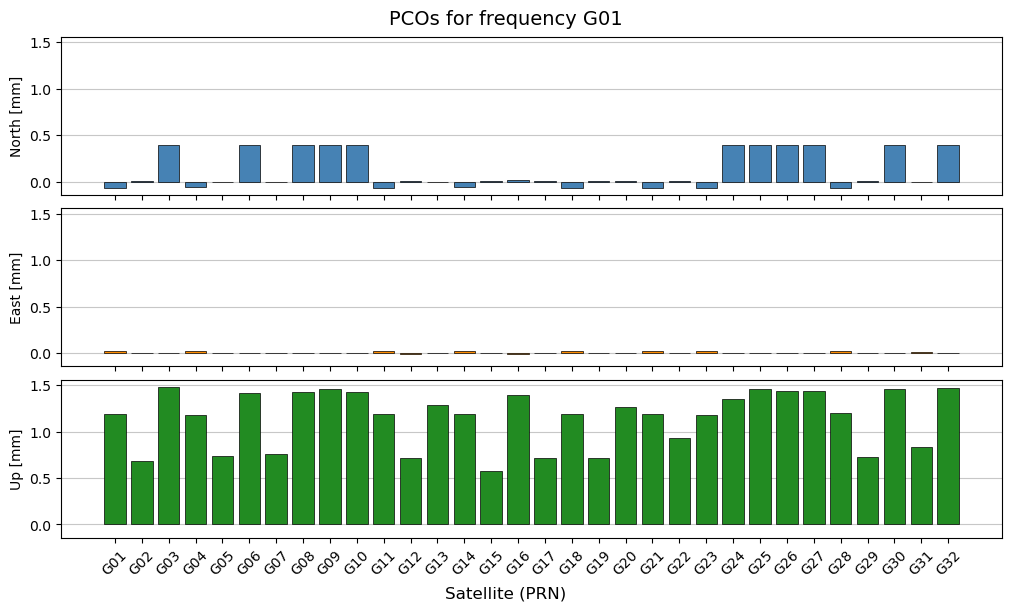

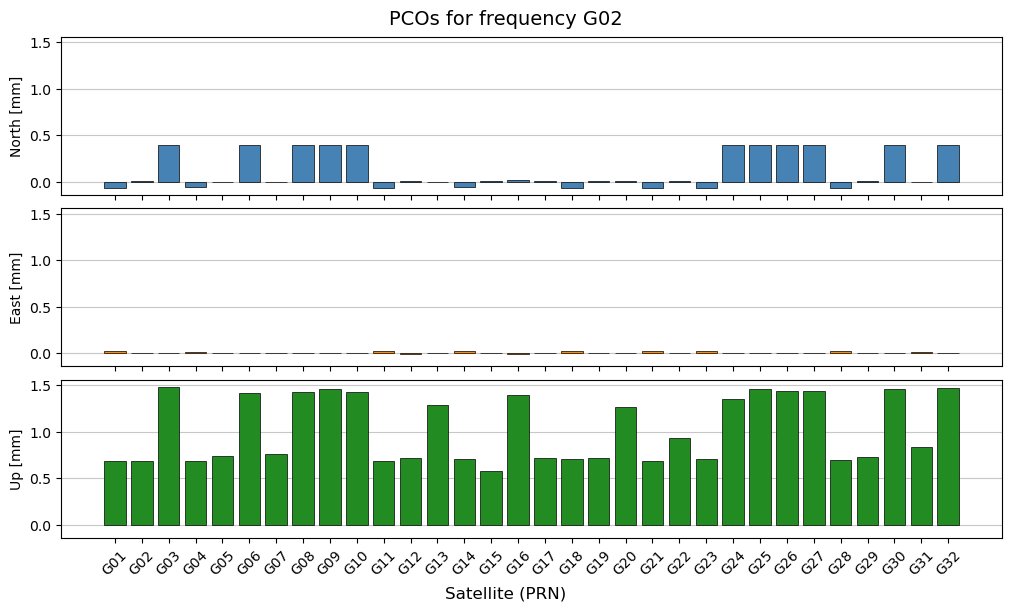

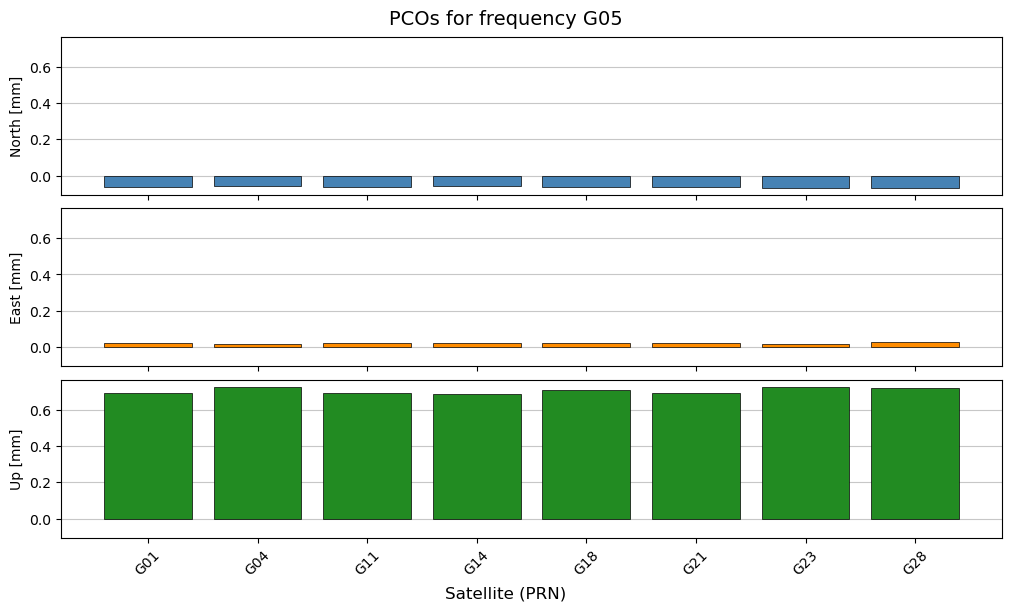

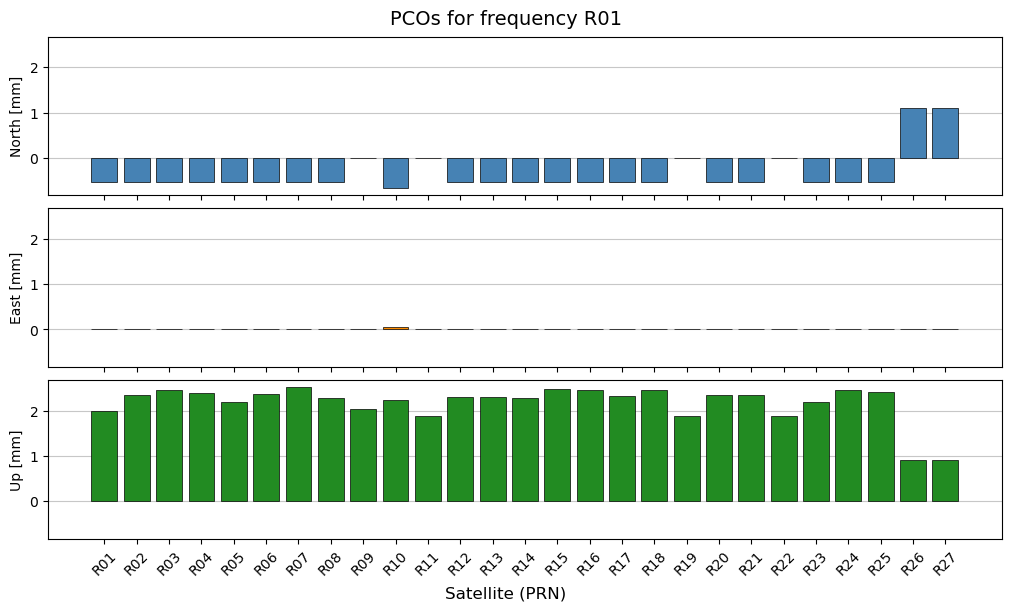

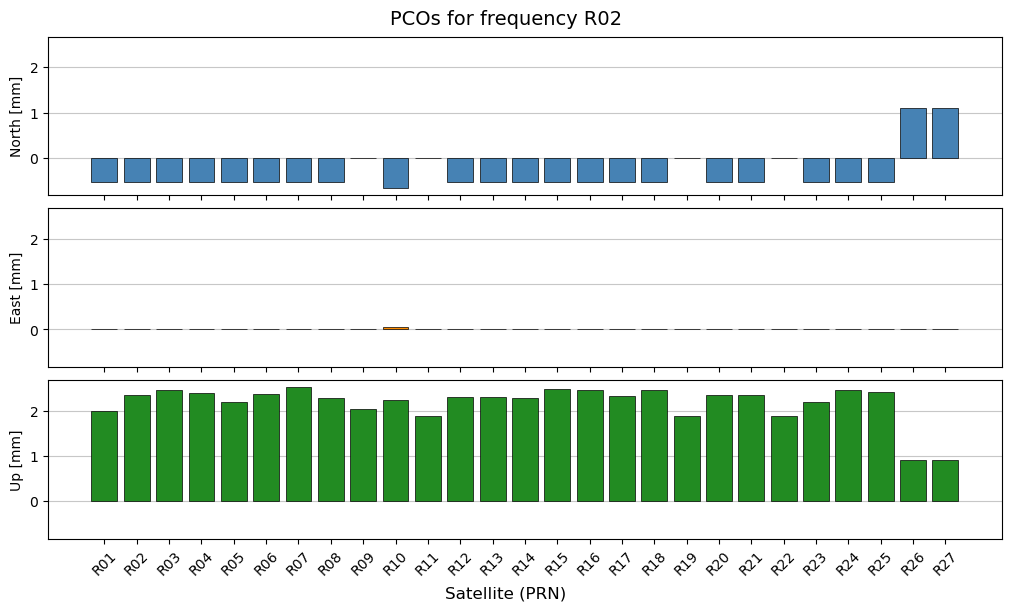

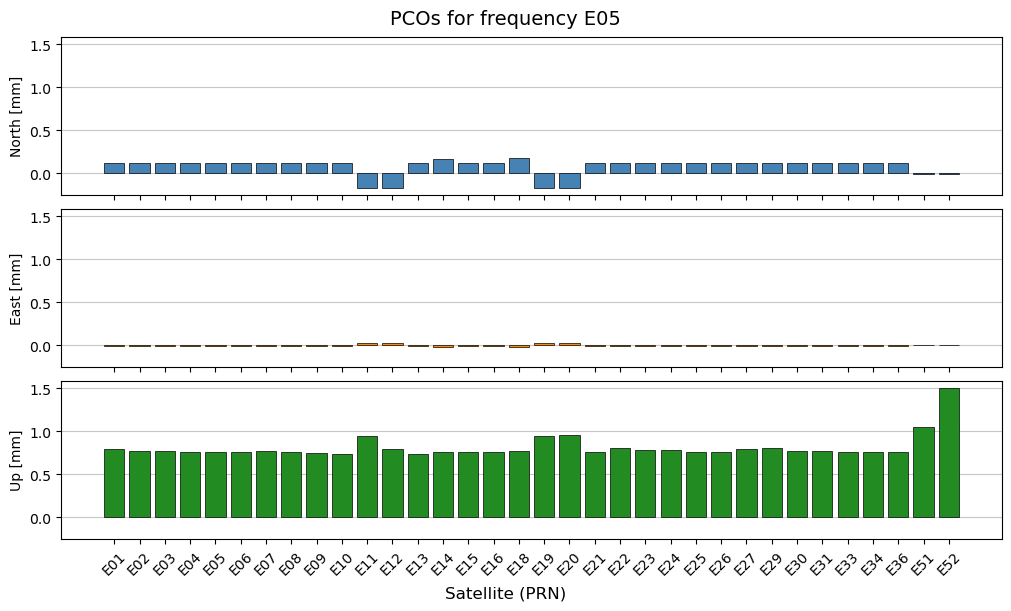

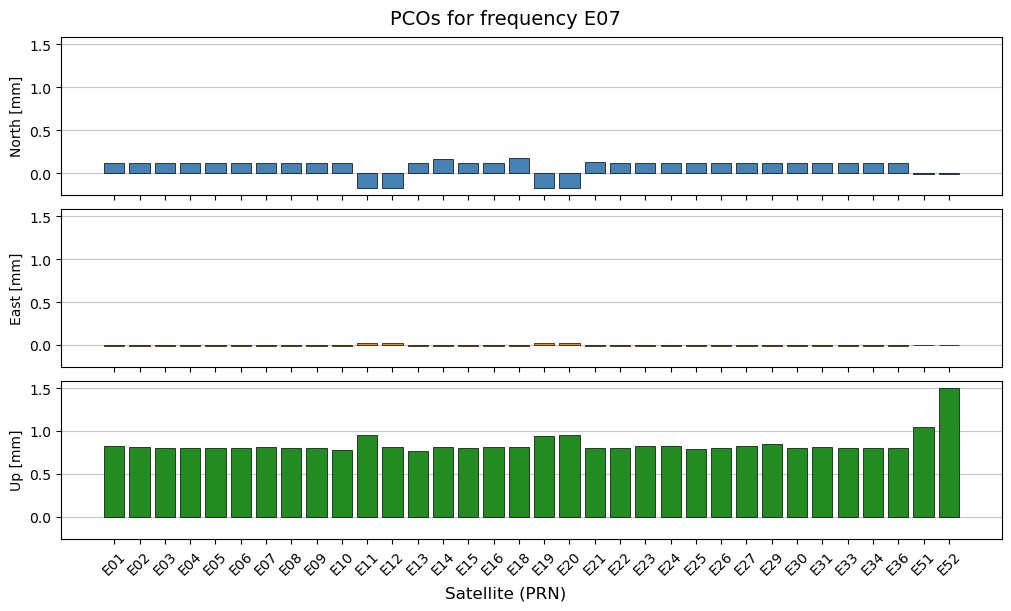

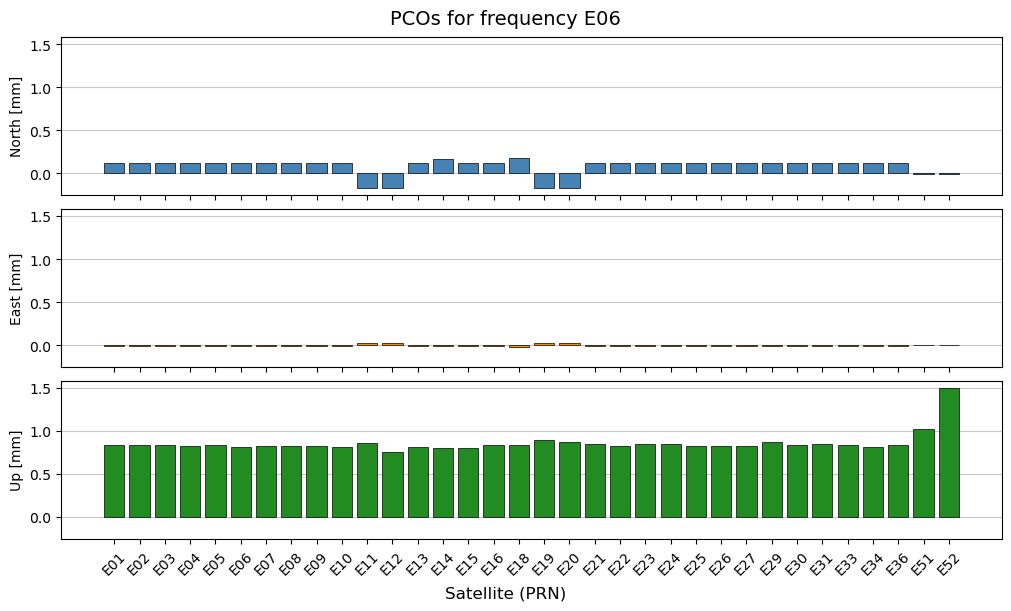

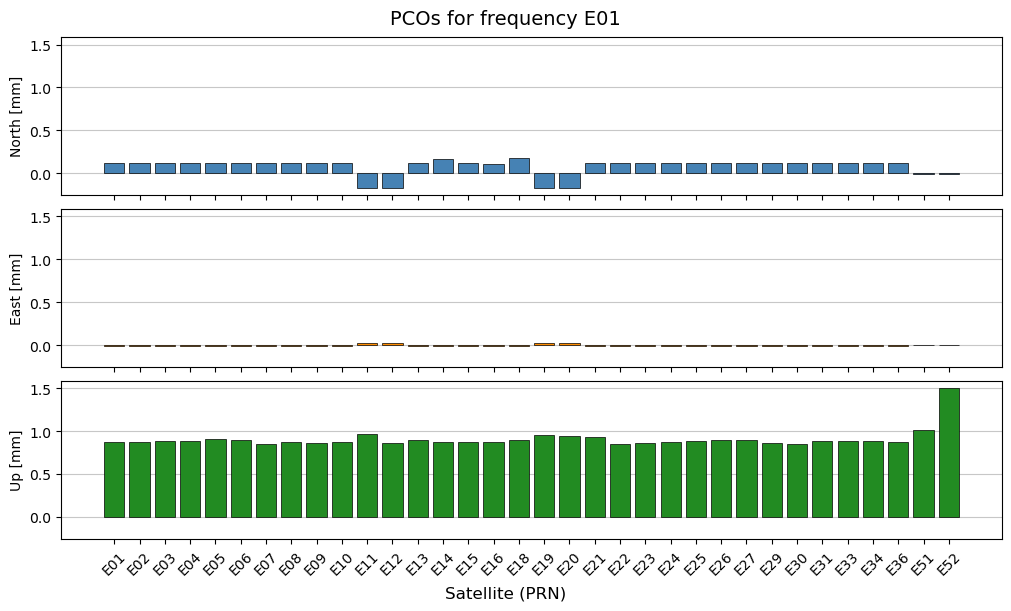

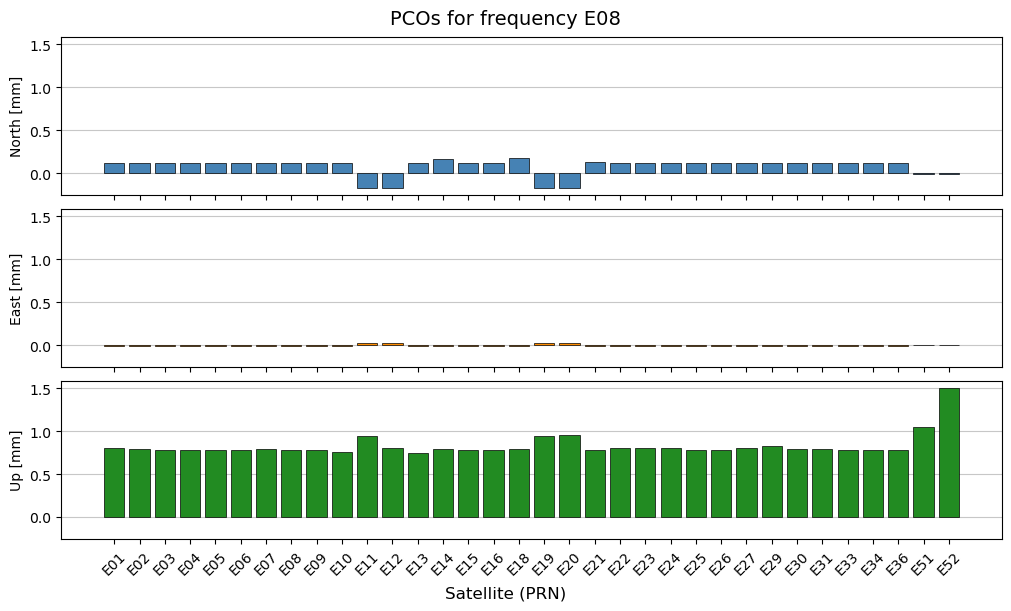

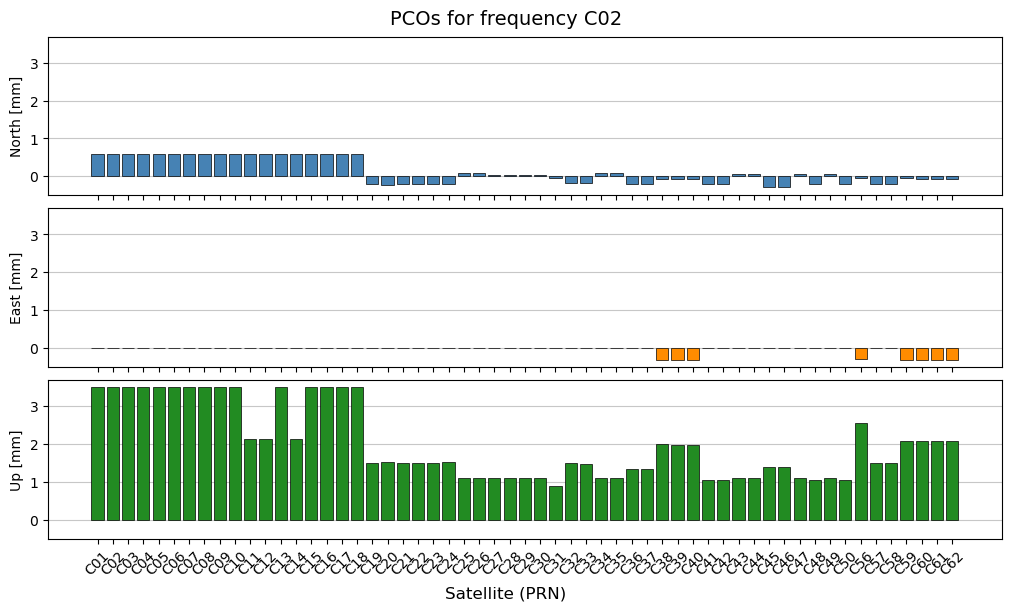

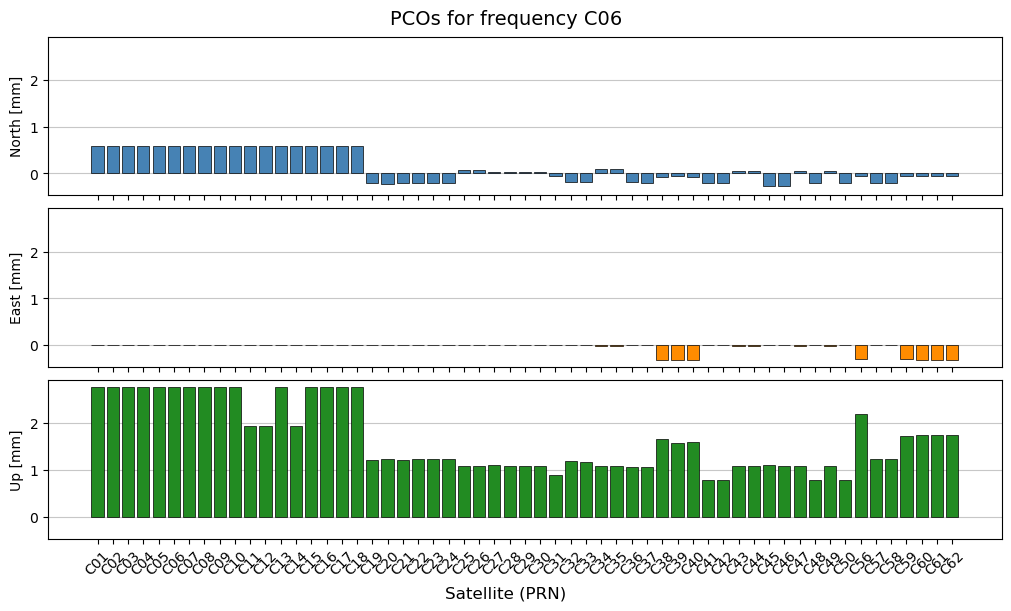

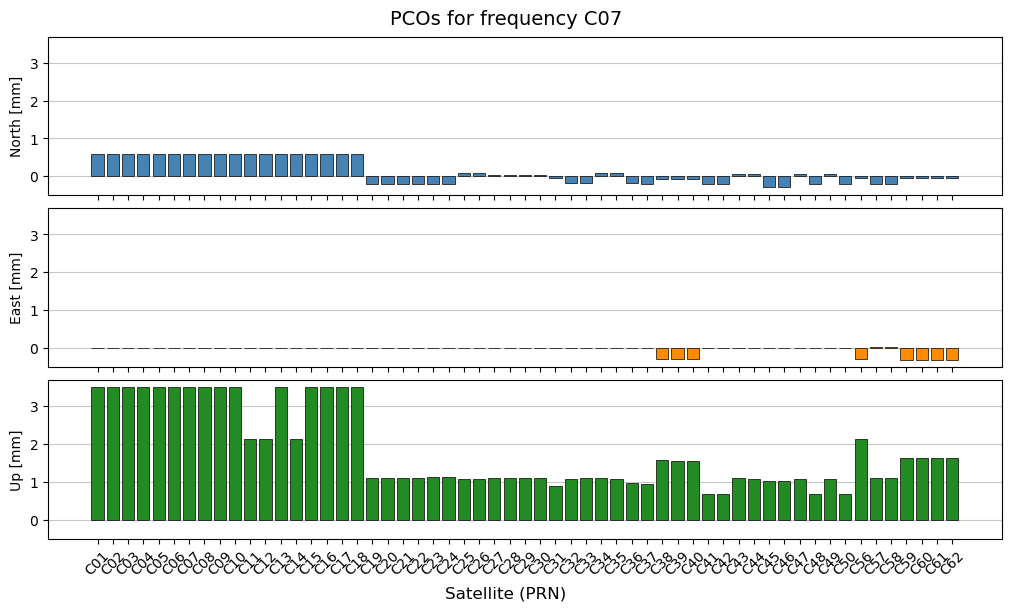

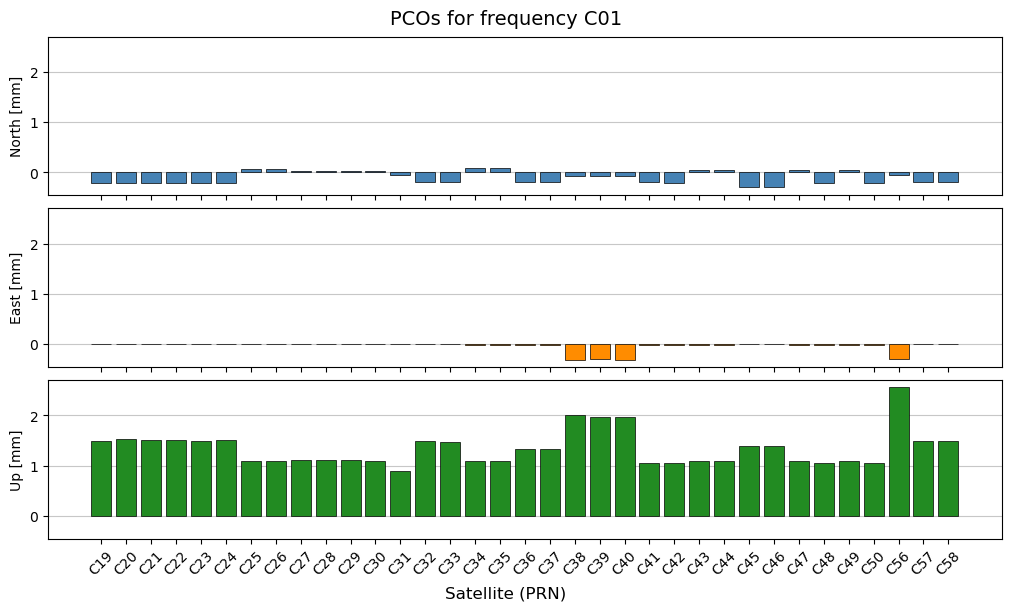

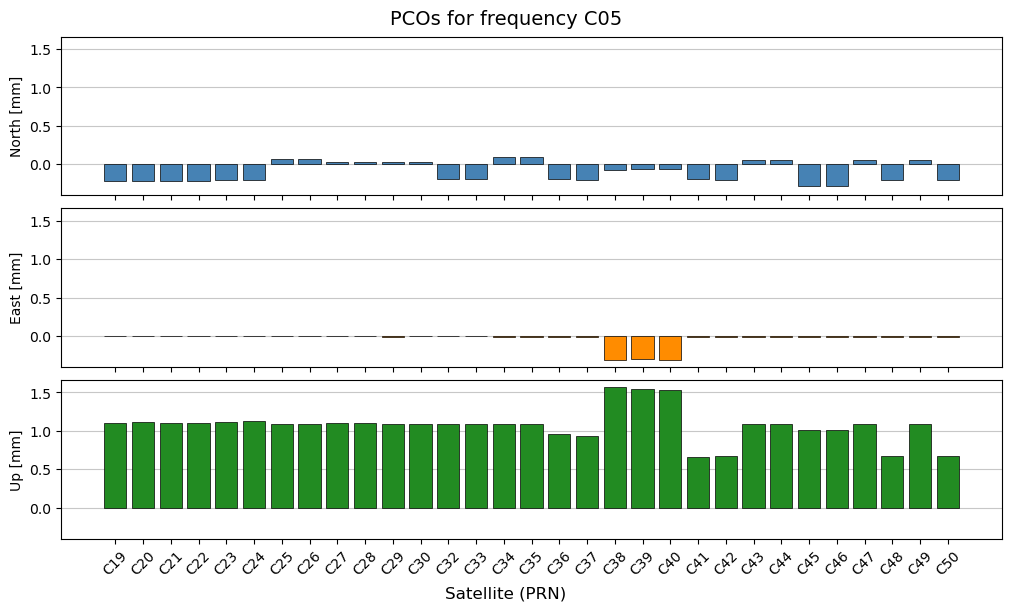

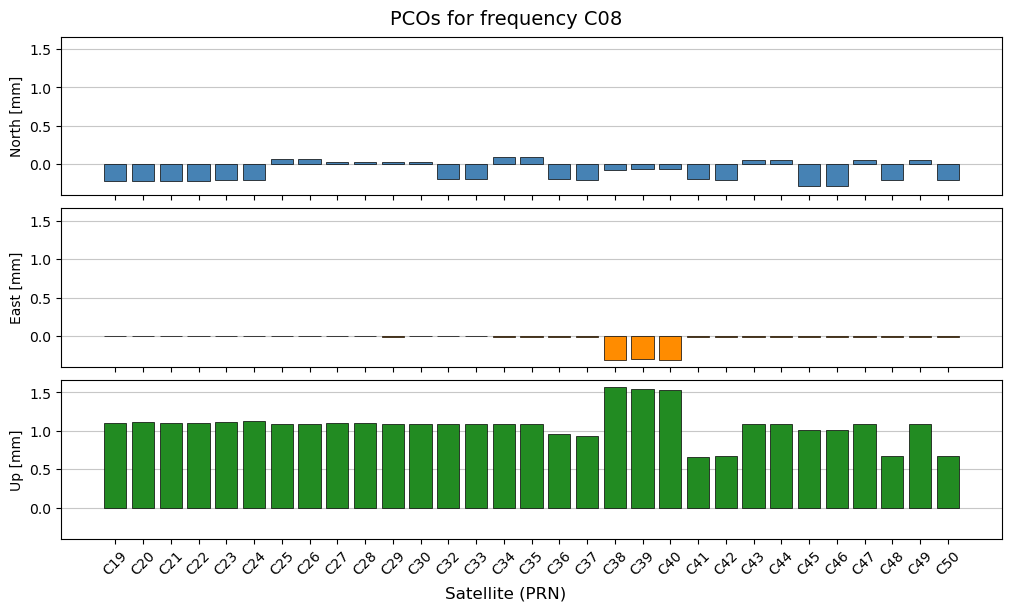

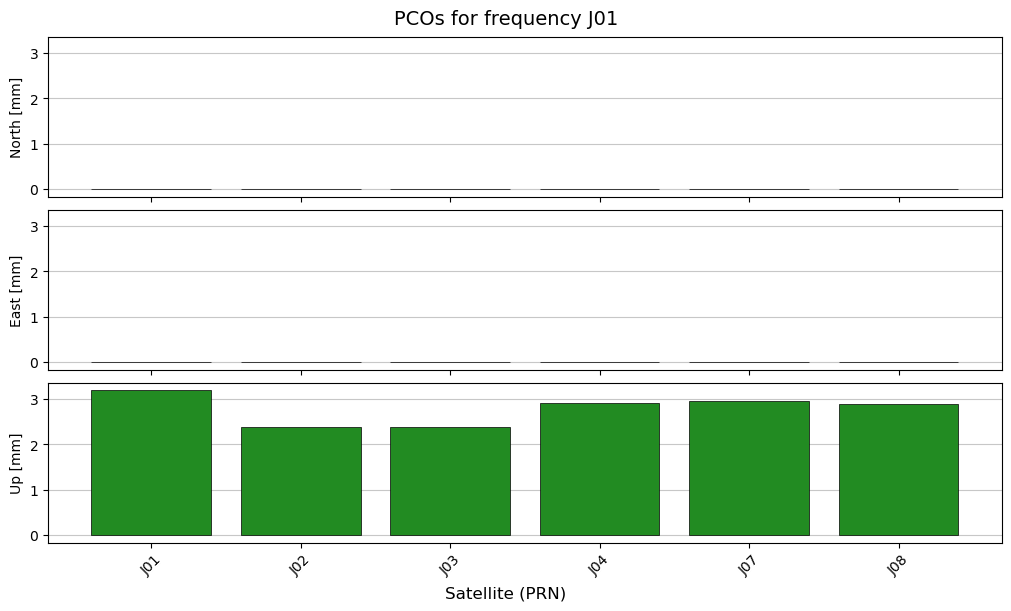

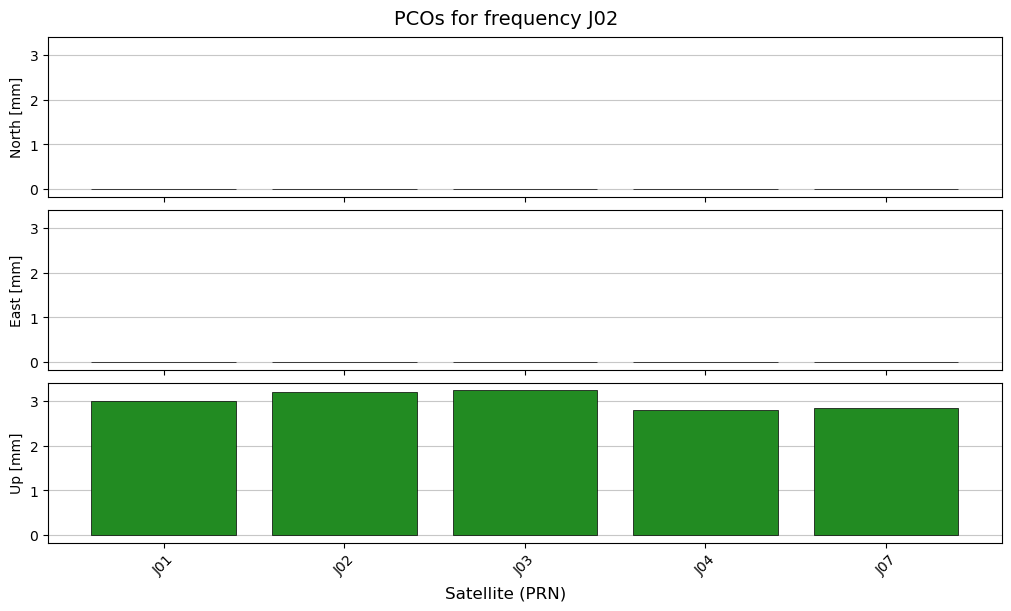

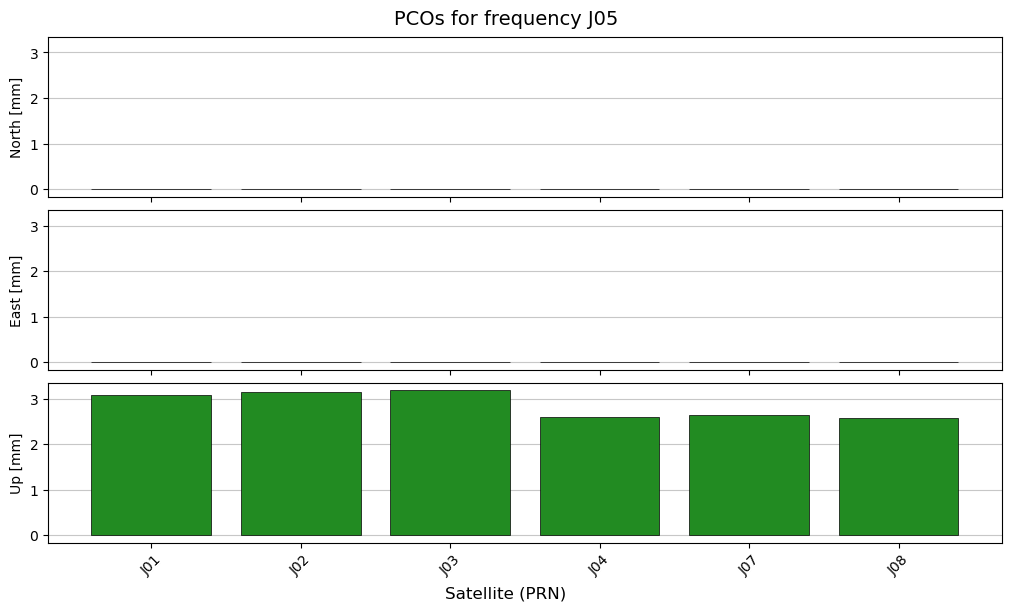

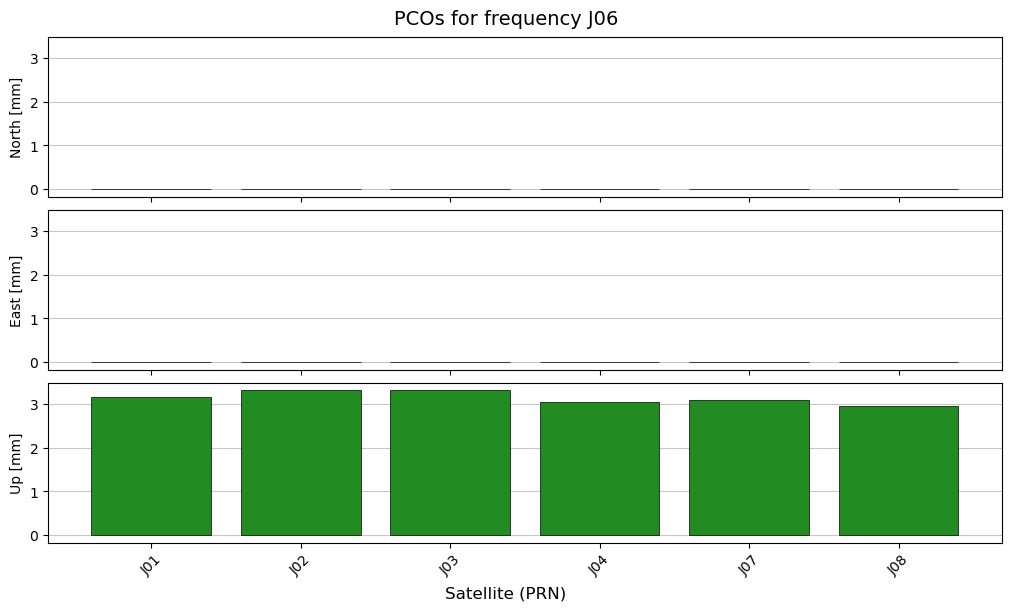

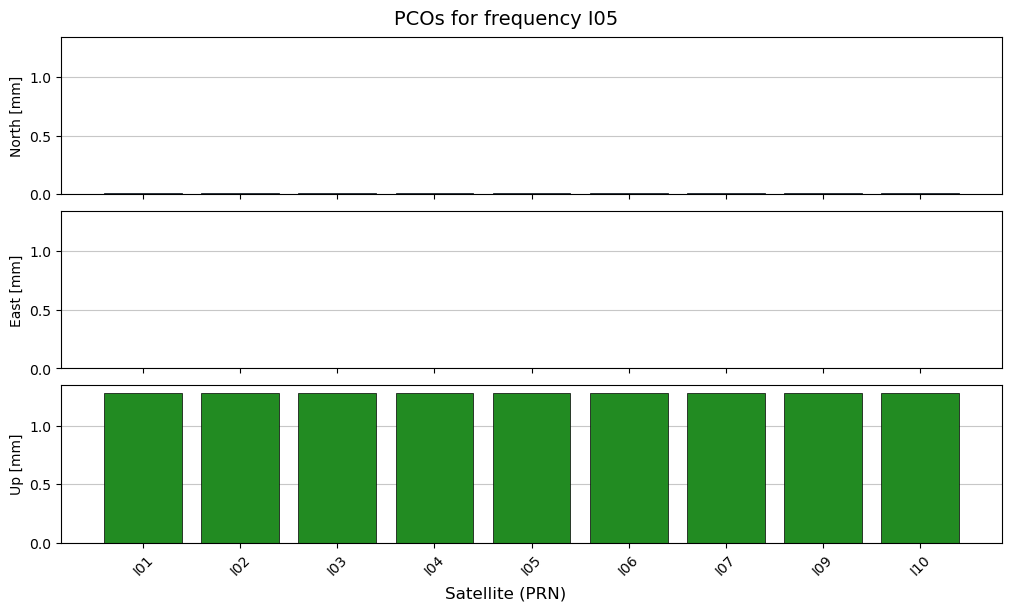

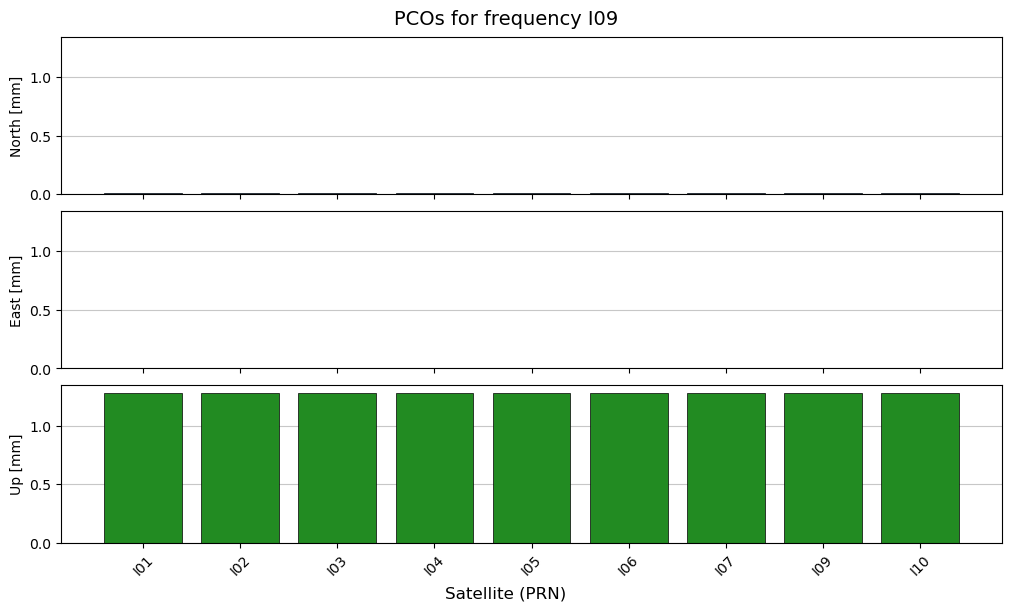

In [2]:
import re
import matplotlib.pyplot as plt


# 1. Prepare data by ordering the PCOs for frequency and satellite related
#__________________________________________________________________________
pco = dict()

# Loop over satellite entries
for sat in data.keys():

    # Get only satellite entries
    if re.match(r'^[a-zA-Z]\d{2}$', sat):

        # Get last date entry
        last_date = list(data[sat].keys())[-1]

        # Get PCOs for frequency entries
        for freq in data[sat][last_date].keys():
            
            if re.match(r'^[a-zA-Z]\d{2}$', freq):
                pco.setdefault(freq, dict()).update({sat: data[sat][last_date][freq]["neu"]})


# 2. Plot PCOs for each frequency
#__________________________________________________________________________
for freq in pco.keys():
    fig, axes = plt.subplots(3, 1, sharex=True, sharey=True, layout="constrained", figsize=(10,6))
    fig.suptitle(f"PCOs for frequency {freq}", fontsize=14)
    
    sats = list(pco[freq].keys())
    labels = ["North [mm]", "East [mm]", "Up [mm]"]
    colors = ["steelblue", "darkorange", "forestgreen"]

    for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
        # Extract values for the actual component (i=0: N, 1: E, 2: U)
        values = [pco[freq][sat][i] for sat in sats]

        ax.set_axisbelow(True)
        ax.grid(axis='y', linestyle='-', alpha=0.7) 
        ax.bar(sats, values, color=color, edgecolor="black", linewidth=0.5)
        ax.set_ylabel(label)

    axes[-1].tick_params(axis="x", labelrotation=45)
    fig.supxlabel("Satellite (PRN)")

    plt.show()      

An example is given how to plot phase center variations (PCV) for a defined antenna (antenna type + radome type).

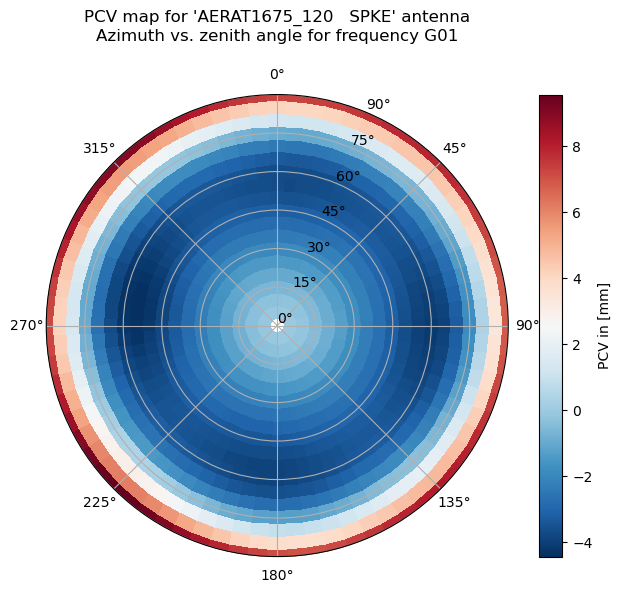

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Choose PCVs for given antenna/radome type and frequency
#____________________________________________________________
ant_type = "AERAT1675_120   SPKE"
freq = "G01"

# Get PCV 2D Data Array (19x73)  (19 rows representing the zenith angle from 0° to 90° and 73 columns with represents 
# the azimuth from  0° to 360° in 5° steps)
pcv = data[ant_type][freq]["azi"]

# 2. Define grid based on ANTEX file format definition
#______________________________________________________
# DAZI = 5.0, ZEN1 = 0.0, ZEN2 = 90.0, DZEN = 5.0
zenith = np.arange(0, 95, 5) # 0, 5, ..., 90 (19 values)
azimuth = np.arange(0, 365, 5)    # 0, 5, ..., 360 (full circle)
theta, r = np.meshgrid(np.radians(azimuth), zenith) # azimuth has to be converted from degree to radian

# 3. Generate Plot
#__________________
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 6))
ax.set_theta_zero_location("N") # North at top
ax.set_theta_direction(-1) # Clockwise

# Plot using pcolormesh (pcv must be transposed to match meshgrid)
#pc = ax.pcolormesh(theta, r, pcv.T, cmap='RdYlBu_r', shading='auto')
pc = ax.pcolormesh(theta, r, pcv.T, cmap="RdBu_r", shading="auto")

# Customizing ticks for zenith angle (0 to 90 degrees)
ax.set_ylim(0, 90)
ax.set_yticks([0, 15, 30, 45, 60, 75, 90])
ax.set_yticklabels(["0°", "15°", "30°", "45°", "60°", "75°", "90°"])

plt.colorbar(pc, label="PCV in [mm]")
plt.title(f"PCV map for '{ant_type}' antenna\nAzimuth vs. zenith angle for frequency {freq}", pad=20)
plt.show()